aim: use nltk package to perform a preprocessing pipeline for sentiment analysis

In [1]:
import nltk 
from nltk.corpus import twitter_samples 
import matplotlib.pyplot as plt 
import random 

In [2]:
# download dataset and load positive and negative tweets 
nltk.download('twitter_samples')
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/suhuang/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.


In [5]:
# report number of positive and negative tweets, dataset type 
print('number of positive tweets: ', len(all_positive_tweets))
print('number of negative tweets: ', len(all_negative_tweets))
print('type of all_positive_tweets: ', type(all_positive_tweets))
print('type of a tween entry: ', type(all_negative_tweets[0]))

number of positive tweets:  5000
number of negative tweets:  5000
type of all_positive_tweets:  <class 'list'>
type of a tween entry:  <class 'str'>


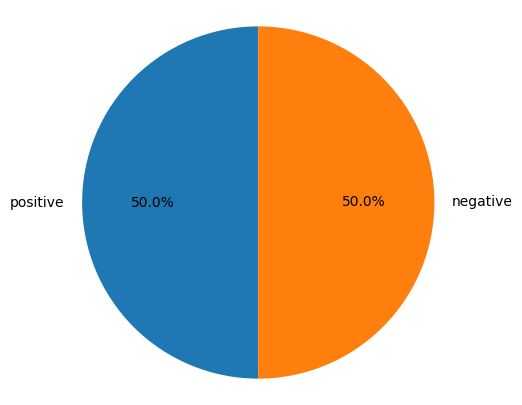

In [8]:
# visualize dataset in a pie chart 
fig = plt.figure(figsize=(5,5))
labels = 'positive', 'negative'
sizes = [len(all_positive_tweets), len(all_negative_tweets)]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.show() 

In [10]:
# print random positive and negative tweet 
print('\033[92m' + all_positive_tweets[random.randint(0,5000)])
print('\033[91m' + all_negative_tweets[random.randint(0,5000)])

@FindBenNeedham it's my birthday today so for my birthday wish I hope there's good news about Ben soon :-)
Full Shaved :(


In [12]:
# select a sample 
tweet = all_positive_tweets[2277]
print(tweet)

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i


In [14]:
nltk.download('stopwords')
import re                                 
import string                              

from nltk.corpus import stopwords          
from nltk.stem import PorterStemmer        
from nltk.tokenize import TweetTokenizer

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/suhuang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
# remove hyperlinks, twitter makrs, styles 
print('\033[92m' + tweet)
print('\033[94m')

# remove old style retweet text "RT"
tweet2 = re.sub(r'^RT[\s]+', '', tweet)

# remove hyperlinks
tweet2 = re.sub(r'https?://[^\s\n\r]+', '', tweet2)

# remove hashtags
# only removing the hash # sign from the word
tweet2 = re.sub(r'#', '', tweet2)

print(tweet2)

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i

My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off… 


In [21]:
# tokenize string 
print('\033[92m' + tweet2)
print('\033[94m')

tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
tweet_tokens = tokenizer.tokenize(tweet2)

print('tokenized string:')
print(tweet_tokens)

My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off… 

tokenized string:
['my', 'beautiful', 'sunflowers', 'on', 'a', 'sunny', 'friday', 'morning', 'off', ':)', 'sunflowers', 'favourites', 'happy', 'friday', 'off', '…']


In [25]:
# remove stopwords and punctuation 
stopwords_english = stopwords.words('english')
print('stop words: ', stopwords_english)
print('punctuation: ', string.punctuation)

print('\033[92m')
print(tweet_tokens)
print('\033[94m')

tweets_clean = []
for word in tweet_tokens: 
    if (word not in stopwords_english and word not in string.punctuation): 
        tweets_clean.append(word)

print('removed stop words and punctuation: ', tweets_clean)

stop words:  ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "

In [28]:
# stemming using porter stemming algorithm 
print('\033[92m')
print(tweets_clean)
print('\033[94m')

stemmer = PorterStemmer() 
tweets_stem = [] 
for word in tweets_clean: 
    stem_word = stemmer.stem(word)
    tweets_stem.append(stem_word)

print('stemmed words: ', tweets_stem)


['beautiful', 'sunflowers', 'sunny', 'friday', 'morning', ':)', 'sunflowers', 'favourites', 'happy', 'friday', '…']

stemmed words:  ['beauti', 'sunflow', 'sunni', 'friday', 'morn', ':)', 'sunflow', 'favourit', 'happi', 'friday', '…']


In [36]:
# using utils function for processing 
from utils import process_tweet 

print('\033[92m')
print(tweet)
print('\033[94m')

tweets_stem = process_tweet(tweet)

print('preprocessed tweet: ', tweets_stem)



My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i

preprocessed tweet:  ['beauti', 'sunflow', 'sunni', 'friday', 'morn', ':)', 'sunflow', 'favourit', 'happi', 'friday', '…']
